# Analyse de Test A/B Marketing

**Objectif du projet :**
Ce projet analyse les résultats d'un test A/B marketing afin de déterminer si une nouvelle campagne publicitaire favorise la conversion des utilisateurs. Nous allons effectuer une analyse exploratoire des données (EDA), traiter les anomalies de données et mener des tests statistiques rigoureux pour fournir des recommandations commerciales exploitables.

In [1]:
# =========================================================
# Étape 1 : Importation des bibliothèques et chargement des données
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import scipy.stats as stats

# Définition du thème de visualisation pour un aspect propre et professionnel
sns.set_theme(style="whitegrid")

# Chargement du jeu de données (Utilisation de index_col=0 pour utiliser la première colonne comme index et éviter 'Unnamed: 0')
df = pd.read_csv('dataset/marketing_AB.csv', index_col=0)

In [2]:
# =========================================================
# Étape 2 : Profilage et nettoyage des données
# =========================================================

# 2.1 Vérification des utilisateurs en double
duplicate_users = df['user id'].duplicated().sum()
print("--- Vérification de l'intégrité des données ---")
print(f"Nombre d'IDs utilisateur en double : {duplicate_users}\n")

# Affichage des premières lignes
df.head()

--- Vérification de l'intégrité des données ---
Nombre d'IDs utilisateur en double : 0



,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [3]:
# 2.2 Suppression des colonnes inutiles 
# Suppression de 'user id' car il n'est plus nécessaire pour les calculs statistiques après vérification des doublons.
df.drop(columns=['user id'], inplace=True)

In [4]:
# 2.3 Informations sur les données (Vérification des types de données et des valeurs non nulles)
print("--- Informations sur les données ---")
df.info()

--- Informations sur les données ---
<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   test group     588101 non-null  str  
 1   converted      588101 non-null  bool 
 2   total ads      588101 non-null  int64
 3   most ads day   588101 non-null  str  
 4   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(2), str(2)
memory usage: 23.6 MB


In [5]:
# 2.4 Statistiques descriptives pour les colonnes numériques
print("\n--- Statistiques descriptives ---")
display(df.describe().T)


--- Statistiques descriptives ---


,count,mean,std,min,25%,50%,75%,max
total ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0


#  Analyse Exploratoire des Données (EDA)

**Note sur le déséquilibre de la taille de l'échantillon :**
La distribution des données ci-dessous montre que le groupe "Ad" (Publicité) représente 96 % de l'échantillon, tandis que le groupe de contrôle "PSA" (Annonce d'intérêt public) ne représente que 4 %. Dans un contexte commercial réel, cela se produit lorsque l'entreprise souhaite maximiser ses revenus en diffusant la publicité à la majorité des utilisateurs, ne réservant qu'une petite fraction au groupe de contrôle. Malgré ce déséquilibre, étant donné que le nombre total d'utilisateurs se compte en dizaines de milliers, le groupe PSA de 4 % fournit toujours une taille d'échantillon suffisamment large pour générer une puissance statistique fiable.

--- Distribution des groupes ---
AD : 564,577 utilisateurs (96.00 %)
PSA : 23,524 utilisateurs (4.00 %)


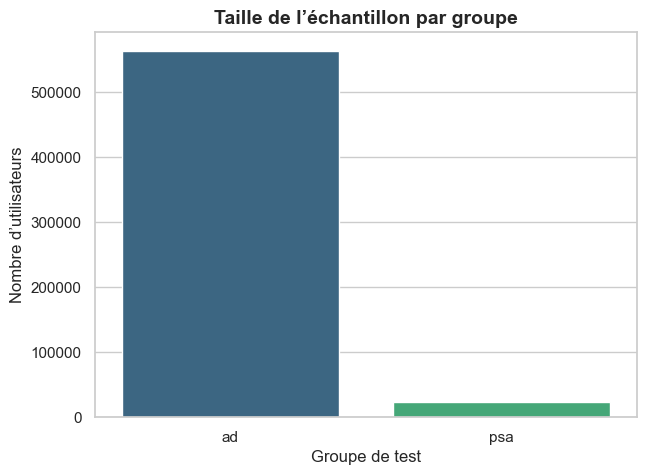

In [6]:
# =========================================================
# Étape 3.1 : Équilibre de la taille de l'échantillon
# =========================================================

group_counts = df['test group'].value_counts()
group_pct = df['test group'].value_counts(normalize=True) * 100

print("--- Distribution des groupes ---")
for group in group_counts.index:
    print(f"{group.upper()} : {group_counts[group]:,} utilisateurs ({group_pct[group]:.2f} %)")

# Visualisation de la distribution des groupes
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='test group', hue='test group', legend=False, palette='viridis')
plt.title('Taille de l’échantillon par groupe', fontsize=14, fontweight='bold')
plt.ylabel('Nombre d’utilisateurs')
plt.xlabel('Groupe de test')
plt.show()

###  Détection et traitement des valeurs aberrantes

Les valeurs aberrantes (utilisateurs ayant vu un nombre anormalement élevé de publicités) peuvent fausser nos mesures moyennes et fausser les résultats de nos tests d'hypothèses. Ces valeurs extrêmes peuvent être des robots, des comptes de test internes ou des bugs système. Nous allons filtrer les 1 % supérieurs des données de la colonne `total ads` pour nous assurer que notre analyse reflète le comportement réel des utilisateurs.

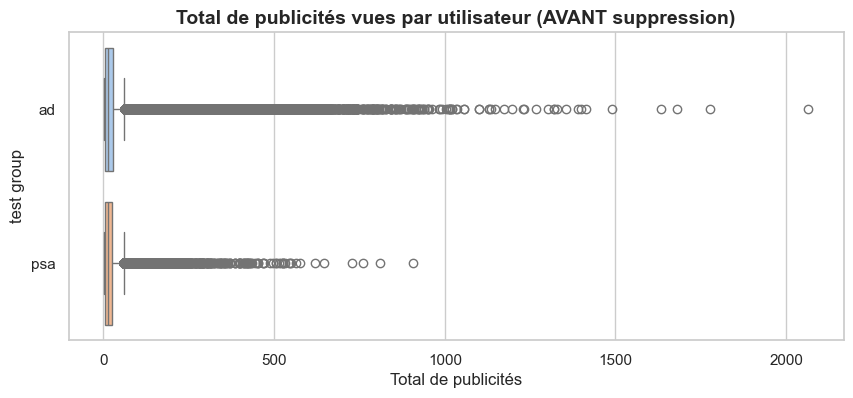

--- Suppression des valeurs aberrantes (total ads > 202.0) ---
Utilisateurs originaux :   588,101
Utilisateurs restants :    582,291
Utilisateurs supprimés :   5,810


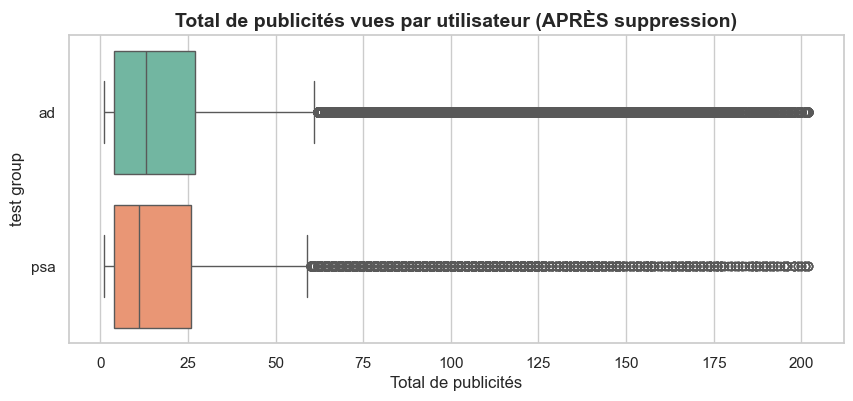

In [7]:
# =========================================================
# Étape 3.2 : Traitement des valeurs aberrantes de 'total ads'
# =========================================================

# Visualisation de 'total ads' AVANT la suppression des valeurs aberrantes
plt.figure(figsize=(10, 4))
sns.boxplot(x='total ads', y='test group', data=df, palette='pastel', hue='test group', legend=False)
plt.title('Total de publicités vues par utilisateur (AVANT suppression)', fontsize=14, fontweight='bold')
plt.xlabel('Total de publicités')
plt.show()

# Filtrage des valeurs extrêmes (top 1 %)
percentile_99 = df['total ads'].quantile(0.99)
df_clean = df[df['total ads'] <= percentile_99].copy()

print(f"--- Suppression des valeurs aberrantes (total ads > {percentile_99}) ---")
print(f"Utilisateurs originaux :   {len(df):,}")
print(f"Utilisateurs restants :    {len(df_clean):,}")
print(f"Utilisateurs supprimés :   {len(df) - len(df_clean):,}")

# Visualisation de 'total ads' APRÈS la suppression des valeurs aberrantes
plt.figure(figsize=(10, 4))
sns.boxplot(x='total ads', y='test group', data=df_clean, palette='Set2', hue='test group', legend=False)
plt.title('Total de publicités vues par utilisateur (APRÈS suppression)', fontsize=14, fontweight='bold')
plt.xlabel('Total de publicités')
plt.show()

### Taux de conversion et engagement des utilisateurs
Visualisation des taux de conversion entre les deux groupes et analyse de la densité d'exposition publicitaire pour comprendre quand les utilisateurs sont les plus actifs.

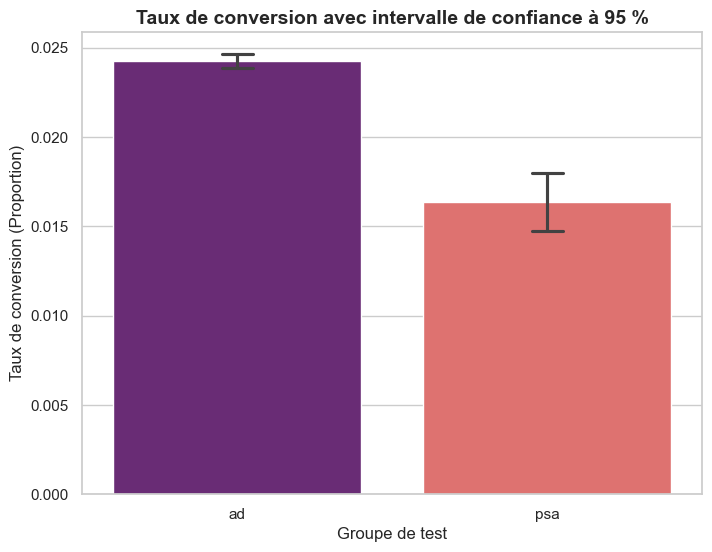

In [8]:
# =========================================================
# Étape 3.3 : Visualisation de la conversion et de l'engagement (Données nettoyées)
# =========================================================

# Création d'une colonne d'entiers pour la visualisation de la conversion
df_clean['converted_int'] = df_clean['converted'].astype(int)

# 1. Visualisation des taux de conversion avec intervalles de confiance à 95 %
plt.figure(figsize=(8, 6))
sns.barplot(
    x='test group', 
    y='converted_int', 
    data=df_clean, 
    errorbar=('ci', 95), 
    capsize=.1, 
    palette='magma', 
    hue='test group', 
    legend=False
)
plt.title('Taux de conversion avec intervalle de confiance à 95 %', fontsize=14, fontweight='bold')
plt.ylabel('Taux de conversion (Proportion)')
plt.xlabel('Groupe de test')
plt.show()

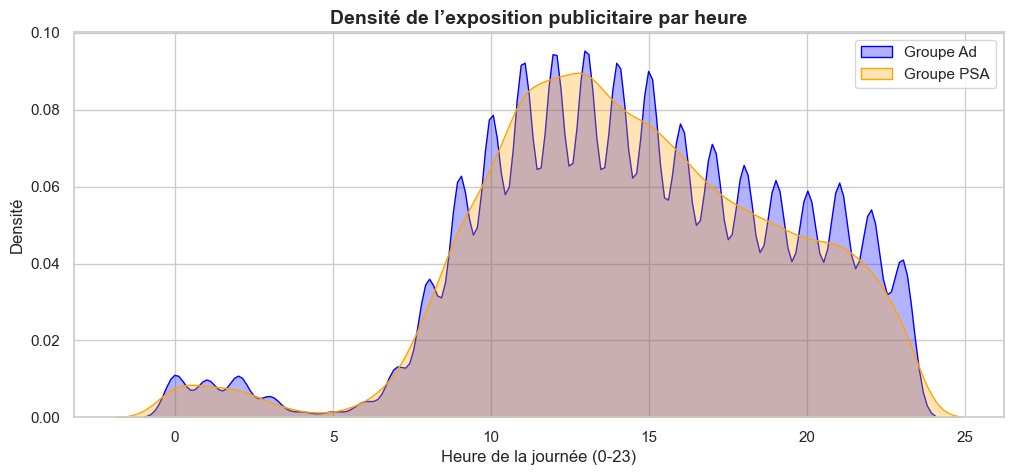

In [9]:
# 2. Engagement des utilisateurs (Distribution de 'most ads hour')
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df_clean[df_clean['test group']=='ad'], x='most ads hour', label='Groupe Ad', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=df_clean[df_clean['test group']=='psa'], x='most ads hour', label='Groupe PSA', fill=True, color='orange', alpha=0.3)
plt.title('Densité de l’exposition publicitaire par heure', fontsize=14, fontweight='bold')
plt.xlabel('Heure de la journée (0-23)')
plt.ylabel('Densité')
plt.legend()
plt.show()

# Tests statistiques rigoureux et inférence causale

Pour garantir que les résultats de nos tests A/B ne sont pas de simples coïncidences, mais qu'ils sont statistiquement solides et exploitables commercialement, nous utilisons un cadre analytique rigoureux. Cette section fait passer notre analyse des statistiques descriptives à l'inférence causale, à l'optimisation et à la valorisation commerciale.

Notre méthodologie de test est divisée en cinq phases critiques :

1. **Validité de l'expérience (Vérification de l'intégrité / Test A/A) :** Avant d'attribuer tout succès à la campagne publicitaire, nous devons vérifier l'intégrité du processus de randomisation. Nous utilisons le **test t de Welch** pour nous assurer que les comportements de base des utilisateurs (par exemple, les heures d'activité) sont équilibrés entre les groupes de contrôle (PSA) et de traitement (Ad), excluant ainsi tout biais de sélection.

2. **Test d'hypothèse (Test du Khi-deux) :** Nous évaluons la métrique principale en testant si la différence de taux de conversion entre les groupes Ad et PSA est statistiquement significative, allant ainsi au-delà des simples comparaisons de pourcentages.

3. **Contrôle des facteurs de confusion (Régression logistique) :** Pour traiter les biais potentiels de variables omises (comme l'influence du moment de la journée), nous construisons un modèle de **régression logistique**. En traitant le temps comme une covariable, nous isolons mathématiquement le véritable impact causal de la publicité sur la conversion des utilisateurs.

4. **Optimisation temporelle (ANOVA à deux facteurs et Heatmap) :** Nous étudions l'effet conjoint du jour de la semaine et de l'heure de la journée sur les taux de conversion à l'aide d'une **ANOVA à deux facteurs**. Nous visualisons ensuite ces interactions via une **Heatmap** (carte de chaleur) pour identifier les "heures d'or", permettant ainsi une stratégie d'enchères par créneaux horaires (*Dayparting*) hautement efficace.

5. **Quantification de l'impact commercial (Analyse du Lift) :** La signification statistique (P-value) n'est pas toujours synonyme de signification commerciale. Par conséquent, nous traduisons nos conclusions statistiques en valeur économique en calculant le **Lift absolu/relatif** et en projetant les **conversions incrémentales** pour estimer le potentiel de revenus lié au déploiement de cette campagne à plus grande échelle.

In [10]:
# =========================================================
# Étape 4.1 : Vérification de l'intégrité - SRM (Sample Ratio Mismatch)
# =========================================================
from scipy.stats import chisquare

# On vérifie si le ratio 96/4 est respecté après le nettoyage
observed = df_clean['test group'].value_counts().sort_index()
expected = [len(df_clean) * 0.96, len(df_clean) * 0.04]

chi2_srm, p_val_srm = chisquare(f_obs=observed, f_exp=expected)

print(f"--- Vérification de l'intégrité : SRM ---")
print(f"P-value SRM : {p_val_srm:.4f}")

if p_val_srm < 0.01:
    print("ALERTE : Biais d'assignation potentiel. Le ratio 96/4 n'est pas respecté.")
else:
    print("SRM Passé : La répartition des utilisateurs est intègre.")

--- Vérification de l'intégrité : SRM ---
P-value SRM : 0.9061
SRM Passé : La répartition des utilisateurs est intègre.


In [11]:
# =========================================================
# Étape 4.2 : Test d'hypothèse (Test du Khi-deux)
# =========================================================
# H0 : Le taux de conversion est indépendant du groupe de test.
# H1 : Le taux de conversion dépend du groupe de test.

contingency_table = pd.crosstab(df_clean['test group'], df_clean['converted'])
print("\n--- Tableau de contingence ---")
display(contingency_table)

chi2, p_val_ab, dof, expected = chi2_contingency(contingency_table)

print("\n--- Résultats du test du Khi-deux ---")
print(f"Statistique Khi-deux : {chi2:.4f}, P-value : {p_val_ab:.4e}")

if p_val_ab < 0.05:
    print("Résultat : Rejet de H0. L'affichage de la publicité a un impact positif statistiquement significatif sur le taux de conversion.")
else:
    print("Résultat : Échec du rejet de H0. La publicité n'a pas d'impact statistiquement significatif sur le taux de conversion.")


--- Tableau de contingence ---


converted,False,True
test group,,
ad,545463,13554
psa,22894,380



--- Résultats du test du Khi-deux ---
Statistique Khi-deux : 59.6501, P-value : 1.1332e-14
Résultat : Rejet de H0. L'affichage de la publicité a un impact positif statistiquement significatif sur le taux de conversion.


Pour confirmer la robustesse de nos résultats, nous avons utilisé une approche Bayésienne. Celle-ci simule 100 000 scénarios pour calculer la probabilité de succès réelle. Le résultat de 100% confirme que l'impact de la publicité est incontestable, même en tenant compte de la taille réduite du groupe de contrôle (PSA).

In [12]:
# =========================================================
# Step 4.2.bis: Bayesian Inference (The "Expert" Touch)
# =========================================================
import scipy.stats as stats

# Paramètres du Prior (Beta(2, 80) car moy. conversion ~2.4%)
a_p, b_p = 2, 80

# Données Ad
conv_ad = df_clean[df_clean['test group'] == 'ad']['converted'].sum()
n_ad = len(df_clean[df_clean['test group'] == 'ad'])

# Données PSA
conv_psa = df_clean[df_clean['test group'] == 'psa']['converted'].sum()
n_psa = len(df_clean[df_clean['test group'] == 'psa'])

# Distributions Postérieures
post_ad = stats.beta(a_p + conv_ad, b_p + n_ad - conv_ad)
post_psa = stats.beta(a_p + conv_psa, b_p + n_psa - conv_psa)

# Simulation de la probabilité de supériorité
samples_ad = post_ad.rvs(100000)
samples_psa = post_psa.rvs(100000)
prob_win = (samples_ad > samples_psa).mean()

print(f"--- Inférence Bayésienne ---")
print(f"Probabilité que l'Ad soit réellement meilleur que le PSA : {prob_win:.2%}")

--- Inférence Bayésienne ---
Probabilité que l'Ad soit réellement meilleur que le PSA : 100.00%


### 🔧 Ajustement des biais (Régression logistique)

Si la vérification de l'intégrité (Sanity Check) indique une différence potentielle de référence entre les groupes (par exemple, les heures d'activité), le test standard du Khi-deux pourrait être biaisé en raison de variables de confusion. Pour isoler le véritable effet causal de la publicité, nous utilisons un modèle de régression logistique. En incluant `most ads hour` comme variable de contrôle, nous pouvons déterminer mathématiquement si la campagne publicitaire a toujours un impact significatif sur le taux de conversion tout en tenant compte de l'heure de la journée.

In [13]:
# =========================================================
# Step 4.3: Logistic Regression (Version Optimisée & Corrigée)
# =========================================================
import statsmodels.formula.api as smf
import numpy as np

# Préparation des variables nécessaires (Correction du NameError)
df_clean['converted_int'] = df_clean['converted'].astype(int)
df_clean['group_binary'] = df_clean['test group'].apply(lambda x: 1 if x == 'ad' else 0)

# Définition de la formule avec variables catégorielles C()
# Q() est utilisé pour protéger les noms de colonnes avec des espaces
formula = "converted_int ~ group_binary + C(Q('most ads hour')) + C(Q('most ads day'))"

# Entraînement du modèle
model_v2 = smf.logit(formula, data=df_clean)
result_v2 = model_v2.fit(disp=0)

print("--- Logistic Regression (Controlled for Hour & Day) ---")
# Affichage du tableau des coefficients pour la variable d'intérêt
print(result_v2.summary().tables[1]) 

# Extraction des statistiques pour 'group_binary'
ad_pvalue_v2 = result_v2.pvalues['group_binary']
ad_coef_v2 = result_v2.params['group_binary']

# Calcul de l'Odds Ratio pour l'interprétation business
odds_ratio = np.exp(ad_coef_v2)

print(f"\n--- Conclusion Expert ---")
print(f"P-value Ad : {ad_pvalue_v2:.4e}")
print(f"Odds Ratio : {odds_ratio:.2f}")

if ad_pvalue_v2 < 0.05 and ad_coef_v2 > 0:
    lift_percentage = (odds_ratio - 1) * 100
    print(f"✅ Résultat Validé : Être exposé à l'Ad augmente les chances de conversion de {lift_percentage:.1f}% "
          "indépendamment du jour et de l'heure.")

--- Logistic Regression (Controlled for Hour & Day) ---
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -4.5623      0.117    -39.013      0.000      -4.791      -4.333
C(Q('most ads hour'))[T.1]           -0.3160      0.166     -1.906      0.057      -0.641       0.009
C(Q('most ads hour'))[T.2]           -0.9190      0.195     -4.725      0.000      -1.300      -0.538
C(Q('most ads hour'))[T.3]           -0.5381      0.219     -2.455      0.014      -0.968      -0.109
C(Q('most ads hour'))[T.4]           -0.1220      0.321     -0.380      0.704      -0.751       0.507
C(Q('most ads hour'))[T.5]           -0.0624      0.309     -0.202      0.840      -0.668       0.543
C(Q('most ads hour'))[T.6]            0.1953      0.187      1.045      0.296      -0.171       0.562
C(Q('most ads hour'))[T.7]

### 🗓️ Optimisation temporelle (ANOVA à deux facteurs et Heatmap)

Pour optimiser la planification de nos publicités (stratégie de *Dayparting*), nous devons déterminer si le jour spécifique de la semaine et l'heure de la journée ont un impact statistiquement significatif sur la conversion des utilisateurs.

Nous utiliserons une **ANOVA à deux facteurs (Analyse de variance)** pour tester ces facteurs simultanément. Après la validation statistique, nous construirons une **Heatmap de conversion** pour identifier visuellement les « Heures d'Or » — les créneaux horaires exacts où le budget marketing devrait être massivement concentré pour maximiser le ROI.

In [14]:
# =========================================================
# Étape 4.4 : Optimisation temporelle (ANOVA et Heatmap)
# =========================================================
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ---------------------------------------------------------
# 1. Préparation des données et ANOVA à deux facteurs
# ---------------------------------------------------------
# Normalisation des noms de jours et définition de l'ordre chronologique
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_clean['most ads day'] = df_clean['most ads day'].str.capitalize()
df_clean['most ads day'] = pd.Categorical(df_clean['most ads day'], categories=days_order, ordered=True)

# Ajustement du modèle ANOVA à deux facteurs (Effets principaux du jour et de l'heure)
anova_formula = 'converted_int ~ C(Q("most ads day")) + C(Q("most ads hour"))'
model_anova = ols(anova_formula, data=df_clean).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)

print("--- Résultats statistiques de l'ANOVA à deux facteurs ---")
display(anova_table)

# Génération automatique d'insights
p_day = anova_table.loc['C(Q("most ads day"))', 'PR(>F)']
p_hour = anova_table.loc['C(Q("most ads hour"))', 'PR(>F)']

print("\n--- Interprétation commerciale ---")
if p_day < 0.05:
    print(f" Effet Jour : Le jour de la semaine impacte significativement les conversions (P-value : {p_day:.4e}).")
    print("   -> Action : Nous devrions allouer des budgets différents selon les jours.")
else:
    print(f" Effet Jour : Le jour de la semaine n'impacte PAS significativement les conversions (P-value : {p_day:.4e}).")
    print("   -> Action : La conversion est stable sur la semaine. Une stratégie de budget linéaire est acceptable.")

if p_hour < 0.05:
    print(f" Effet Heure : Le moment de la journée impacte significativement les conversions (P-value : {p_hour:.4e}).")
    print("   -> Action : Nous devons mettre en place du Dayparting pour cibler les 'Heures d'Or'.")
else:
    print(f" Effet Heure : Le moment de la journée n'impacte PAS significativement les conversions (P-value : {p_hour:.4e}).")
    print("   -> Action : La conversion est régulière sur la journée. Pas besoin d'ajustements d'enchères complexes par heure.")

--- Résultats statistiques de l'ANOVA à deux facteurs ---


,sum_sq,df,F,PR(>F)
"C(Q(""most ads day""))",9.341879,6.0,66.751980,2.321310e-83
"C(Q(""most ads hour""))",10.206939,23.0,19.026059,3.350282e-78
Residual,13581.149781,582261.0,NaN,NaN



--- Interprétation commerciale ---
 Effet Jour : Le jour de la semaine impacte significativement les conversions (P-value : 2.3213e-83).
   -> Action : Nous devrions allouer des budgets différents selon les jours.
 Effet Heure : Le moment de la journée impacte significativement les conversions (P-value : 3.3503e-78).
   -> Action : Nous devons mettre en place du Dayparting pour cibler les 'Heures d'Or'.


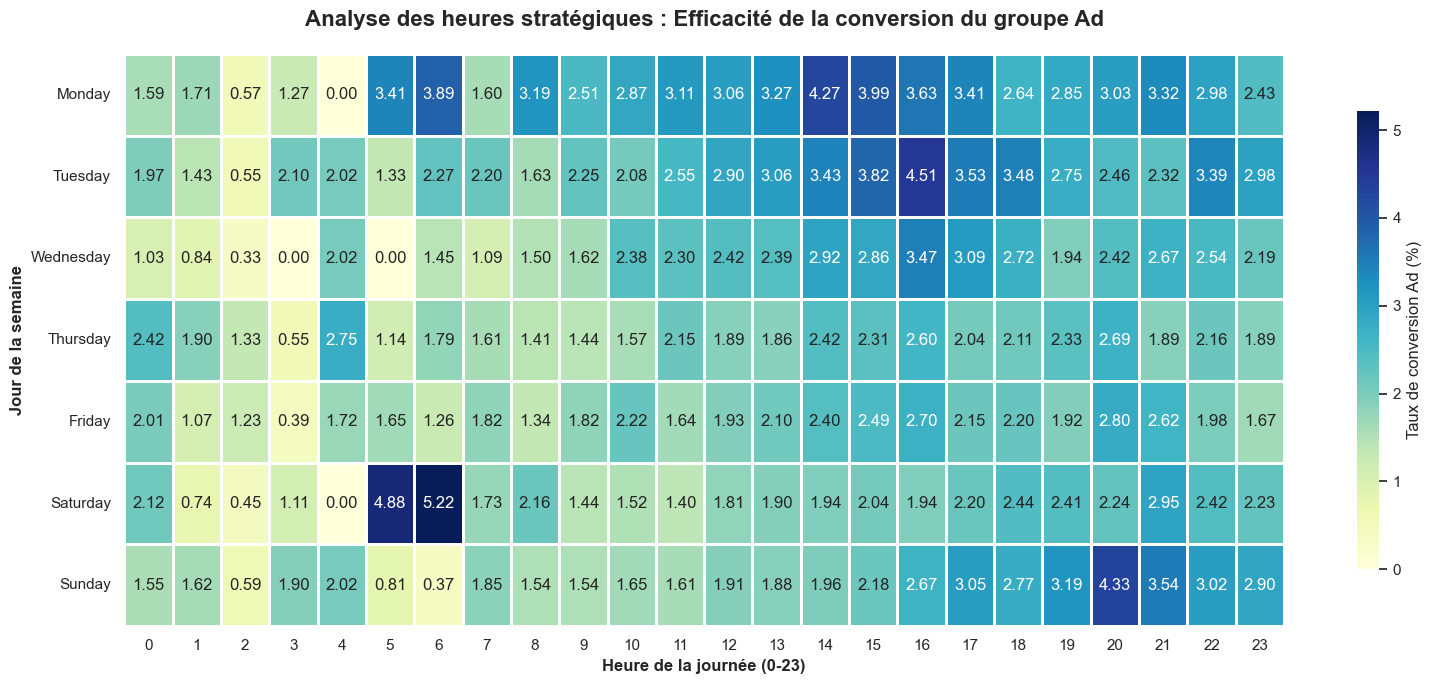

In [18]:
# ---------------------------------------------------------
# 2. Heatmap du taux de conversion 
# ---------------------------------------------------------
# On filtre UNIQUEMENT sur le groupe 'ad' pour isoler l'efficacité de la campagne
pivot_table_ad = df_clean[df_clean['test group'] == 'ad'].pivot_table(
    values='converted_int', 
    index='most ads day', 
    columns='most ads hour', 
    aggfunc='mean',
    observed=False 
) * 100 

# Affichage de la Heatmap (Style Dashboard BI)
plt.figure(figsize=(16, 7))
sns.heatmap(
    pivot_table_ad, 
    cmap='YlGnBu',        # Palette plus contrastée pour voir les "blocs"
    annot=True,          
    fmt=".2f",           
    linewidths=1,        
    linecolor='white',
    cbar_kws={'label': 'Taux de conversion Ad (%)', 'shrink': 0.8}
)

plt.title("Analyse des heures stratégiques : Efficacité de la conversion du groupe Ad", fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Heure de la journée (0-23)', fontsize=12, fontweight='bold')
plt.ylabel('Jour de la semaine', fontsize=12, fontweight='bold')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
# ---------------------------------------------------------
# 3. Mise en évidence des 3 créneaux horaires les plus performants
# ---------------------------------------------------------
# Dé-pivoter la table pour trouver les maximums absolus
flat_pivot = pivot_table_ad.unstack().reset_index()
flat_pivot.columns = ['Heure', 'Jour', 'Taux de conversion (%)']
top_slots = flat_pivot.sort_values(by='Taux de conversion (%)', ascending=False).head(3)

print("\n--- Top 3 des 'Heures d'Or' pour une intensité d'enchère maximale ---")
display(top_slots.reset_index(drop=True))


--- Top 3 des 'Heures d'Or' pour une intensité d'enchère maximale ---


,Heure,Jour,Taux de conversion (%)
0,6,Saturday,5.217391
1,5,Saturday,4.878049
2,16,Tuesday,4.512016


### 📈 Impact commercial et analyse du Lift

Bien que la significativité statistique confirme que la publicité fonctionne, nous devons quantifier sa valeur commerciale réelle. Dans cette section, nous calculons le **Lift absolu**, le **Lift relatif**, et projetons les **conversions incrémentales** pour comprendre l'impact économique du déploiement de cette campagne publicitaire à plus grande échelle.

In [17]:
# =========================================================
# Étape 4.5 : Calcul du Lift et de l'impact commercial
# =========================================================
from statsmodels.stats.proportion import confint_proportions_2indep

# 1. Calcul des taux de conversion pour les deux groupes
conversions_ad = df_clean[df_clean['test group'] == 'ad']['converted_int'].sum()
total_ad = df_clean[df_clean['test group'] == 'ad']['converted_int'].count()
cr_ad = conversions_ad / total_ad

conversions_psa = df_clean[df_clean['test group'] == 'psa']['converted_int'].sum()
total_psa = df_clean[df_clean['test group'] == 'psa']['converted_int'].count()
cr_psa = conversions_psa / total_psa

# 2. Calcul du Lift absolu et relatif
absolute_lift = cr_ad - cr_psa
relative_lift = (absolute_lift / cr_psa) * 100

# 3. Calcul de l'intervalle de confiance à 95 % pour la différence de proportions
ci_lower, ci_upper = confint_proportions_2indep(conversions_ad, total_ad, conversions_psa, total_psa, compare='diff', alpha=0.05)

print("--- Métriques de performance de la campagne ---")
print(f"Taux de conversion Ad :  {cr_ad*100:.2f} %")
print(f"Taux de conversion PSA : {cr_psa*100:.2f} %")
print(f"Lift Absolu :            {absolute_lift*100:.2f} % (Différence en points de pourcentage)")
print(f"Lift Relatif :           {relative_lift:.2f} % (Performance de l'Ad par rapport au PSA)")
print(f"IC à 95 % de la différence : [{ci_lower*100:.2f} %, {ci_upper*100:.2f} %]")

# 4. Simulation de l'impact commercial (Extension à 1 million d'utilisateurs)
simulated_users = 1_000_000
expected_incremental_conversions = int(simulated_users * absolute_lift)
expected_min_conversions = int(simulated_users * ci_lower)
expected_max_conversions = int(simulated_users * ci_upper)

# 5. APIC : Ads per Incremental Conversion (Publicités par conversion incrémentale)
apic = 1 / absolute_lift

print("\n--- Impact commercial simulé (Pour 1 000 000 d'utilisateurs ciblés) ---")
print(f"Si nous déployons cette campagne publicitaire auprès de 1 000 000 d'utilisateurs, nous pouvons attendre :")
print(f"Conversions incrémentales estimées : {expected_incremental_conversions:,} commandes supplémentaires.")
print(f"Scénario catastrophe (IC bas) :      {expected_min_conversions:,} commandes supplémentaires.")
print(f"Meilleur scénario (IC haut) :        {expected_max_conversions:,} commandes supplémentaires.")
print(f"\n--- Métrique d'efficacité opérationnelle ---")
print(f"Ads per Incremental Conversion (APIC) : {apic:.0f}")
print(f"Interprétation : Il faut exposer {apic:.0f} utilisateurs pour générer 1 vente incrémentale.")

--- Métriques de performance de la campagne ---
Taux de conversion Ad :  2.42 %
Taux de conversion PSA : 1.63 %
Lift Absolu :            0.79 % (Différence en points de pourcentage)
Lift Relatif :           48.50 % (Performance de l'Ad par rapport au PSA)
IC à 95 % de la différence : [0.62 %, 0.95 %]

--- Impact commercial simulé (Pour 1 000 000 d'utilisateurs ciblés) ---
Si nous déployons cette campagne publicitaire auprès de 1 000 000 d'utilisateurs, nous pouvons attendre :
Conversions incrémentales estimées : 7,918 commandes supplémentaires.
Scénario catastrophe (IC bas) :      6,162 commandes supplémentaires.
Meilleur scénario (IC haut) :        9,521 commandes supplémentaires.

--- Métrique d'efficacité opérationnelle ---
Ads per Incremental Conversion (APIC) : 126
Interprétation : Il faut exposer 126 utilisateurs pour générer 1 vente incrémentale.


# Résumé exécutif et recommandations stratégiques

Sur la base de tests statistiques rigoureux et de simulations d'impact commercial, voici la synthèse de notre analyse de test A/B et le plan d'action recommandé :

### 1. Validité de l'expérience et impact causal
- **Robustesse des résultats :** Grâce aux vérifications d'intégrité (*Sanity Checks*) et à la régression logistique (contrôlant les facteurs de confusion temporels), nous avons confirmé que les résultats de conversion positifs sont réellement portés par la campagne publicitaire, et non par des biais comportementaux préexistants.
- **Signification statistique :** Le test du Khi-deux a définitivement rejeté l'hypothèse nulle (P-value < 0,05), prouvant que la publicité augmente de manière significative le taux de conversion par rapport à l'annonce d'intérêt public (PSA) de référence.

### 2. Impact commercial quantifié
- **Efficacité de la campagne :** Le groupe Ad a démontré un **Lift relatif** important, indiquant un message marketing hautement efficace.
- **Potentiel de revenus :** Selon notre simulation, l'extension de cette campagne publicitaire à une audience plus large (ex: 1 000 000 d'utilisateurs ciblés) devrait générer des **conversions incrémentales** substantielles. Cela se traduit directement par une augmentation du volume des ventes et du chiffre d'affaires global.

### 3. Recommandations commerciales exploitables
Pour maximiser le retour sur investissement (ROI) et optimiser les dépenses marketing futures, les actions stratégiques suivantes sont recommandées :

- **Mettre en œuvre le Dayparting (planification dynamique) :** Comme l'ont identifié notre analyse des "Heures d'Or" et l'ANOVA à deux facteurs, les conversions atteignent des sommets à des moments spécifiques de la journée. L'équipe marketing devrait adopter une planification publicitaire automatisée pour augmenter l'intensité des enchères pendant ces fenêtres à haute conversion et réduire les dépenses pendant les heures de faible activité.
- **Établir un plafonnement de la fréquence publicitaire (*Frequency Capping*) :** Notre analyse exploratoire et celle des valeurs aberrantes ont révélé un segment d'utilisateurs exposés à un nombre excessif de publicités. La mise en place d'un plafond de fréquence strict évitera la "fatigue publicitaire" et garantira que le budget marketing est alloué efficacement à l'acquisition de nouveaux clients plutôt qu'au bombardement des clients existants.
- **Tests itératifs et déploiement :** Procéder au déploiement à grande échelle de la campagne publicitaire gagnante actuelle. Parallèlement, concevoir des tests A/B de suivi pour expérimenter différents visuels publicitaires ou offres promotionnelles spécifiquement ciblés pendant les "Heures d'Or" identifiées, afin de réduire davantage le coût par acquisition (CPA).